In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
model = tf.keras.models.load_model(r"..\Models\inference_model.keras")  # Update path
last_conv_layer_name = "conv3_1"  # Example for ResNet50, change based on your model

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
def get_layercam(model, img_tensor, class_index, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    
    # Element-wise ReLU(gradients) * activations
    relu_grads = tf.nn.relu(grads)
    weights = relu_grads * conv_outputs
    
    # Sum along channels
    cam = tf.reduce_sum(weights, axis=-1).numpy()[0]
    
    # Normalize
    cam = np.maximum(cam, 0)
    cam = cam / cam.max() if cam.max() != 0 else cam
    return cam


In [4]:
def preprocess_image(img_path, target_size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    #img_array = img_array / 255.0
    return np.expand_dims(img_array, axis=0), img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


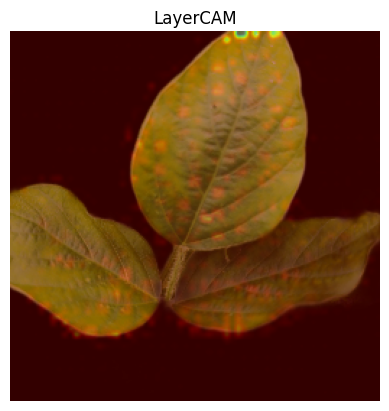

In [11]:
img_tensor, original_img = preprocess_image(r"..\potassium_deficiency_1014.png", (256, 256))
pred = model.predict(img_tensor)
pred_class = np.argmax(pred[0])

layercam_output = get_layercam(model, img_tensor, pred_class, last_conv_layer_name)

# Resize CAM to match input size
layercam_resized = cv2.resize(layercam_output, (original_img.size[0], original_img.size[1]))

# Overlay
heatmap = cv2.applyColorMap(np.uint8(255 * layercam_resized), cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(np.array(original_img).astype("uint8"), 0.6, heatmap, 0.4, 0)

plt.imshow(superimposed_img)
plt.title("LayerCAM")
plt.axis('off')
plt.show()
